# Clinical Trials at Scale — Distributed SQL Analytics on Databricks


## Analysing 573,000 Clinical Trial Records with Spark SQL

This notebook analyses clinical trial data registered in the USA, sourced from [ClinicalTrials.gov](https://clinicaltrials.gov/). The dataset contains over 570,000 records of individual clinical trials with information including study type, status, conditions, sponsors, and dates. The data resides in **Unity Catalog** on Databricks and is queried through a combination of PySpark and Spark SQL, answering four analytical questions a health-research analyst would face: the composition of the trial registry, the public-health conditions attracting the most research, typical trial duration, and the three-decade trend in completed Alzheimer's studies.


In [0]:
%python
# The clinical trials dataset will be loaded from Unity Catalog
# inferSchema=True allows Spark to automatically detect column types rather than treating everything as strings
# header=True tells the CSV reader that the first row contains column names
clinical_trials_df = spark.read.csv(
    "/Volumes/teaching/datasets/assignment_2/task_1/ctg-studies.csv",
    header=True,
    inferSchema=True,
    multiLine=True,       # Handles fields that contain newline characters
    escape='"',           # Handles escaped quotes within quoted fields
    quote='"'             # Tells Spark that double quotes enclose fields containing delimiters
)

# Register as a temporary SQL view to enable querying
clinical_trials_df.createOrReplaceTempView("clinical_trials")

# Verify the load — check schema and row count
clinical_trials_df.printSchema()
print(f"Total records: {clinical_trials_df.count()}")

root
 |-- NCT Number: string (nullable = true)
 |-- Study Title: string (nullable = true)
 |-- Acronym: string (nullable = true)
 |-- Study Status: string (nullable = true)
 |-- Conditions: string (nullable = true)
 |-- Interventions: string (nullable = true)
 |-- Sponsor: string (nullable = true)
 |-- Collaborators: string (nullable = true)
 |-- Enrollment: integer (nullable = true)
 |-- Funder Type: string (nullable = true)
 |-- Study Type: string (nullable = true)
 |-- Study Design: string (nullable = true)
 |-- Start Date: timestamp (nullable = true)
 |-- Completion Date: timestamp (nullable = true)

Total records: 572935


Here we are using `inferSchema=True` rather than manually defining a schema. If this was a production Big Data pipeline (where data would usually be coming in batches), I'd typically need to define the schema explicitly for performance (because this avoids an extra pass over the data) and reliability. However, for an analytical task like this where we're exploring the data, `inferSchema` is pragmatic and lets Spark determine appropriate types. The trade-off is a small performance cost on load, which is acceptable for a one-off analysis.

`header=True` tells Spark to use first row of the csv file as header rows for the dataset.

`quote='"'` tells Spark that fields wrapped in double quotes should be treated as a single value even if they contain commas. This is actually the default, but being explicit ensures it's not overridden.

`multiLine=True` handles the case where a quoted field spans multiple lines. By default Spark assumes one row per line for performance (it can split the file across partitions at line boundaries). Enabling multiLine sacrifices some parallelism but ensures correctness. `multiLine=True` has a performance cost though — Spark can no longer split the file at arbitrary line boundaries for parallel reading, since it needs to be aware of whether a newline is inside a quoted field or is a genuine row boundary. For 572,935 rows this is negligible, but in a truly massive dataset (billions of rows) one would want to consider pre-cleaning the data or using a more robust file format like Parquet.

`escape='"'` handles the edge case where a quoted field itself contains a quote character, represented as "" in standard CSV format.

Next, we register the DataFrame as a temporary view so that we can complete the analysis for this task using Spark SQL. This lets us write SQL queries against the data while still having DataFrame access for any supplementary operations.

Output shows that the dataset contains 14 columns with all string datatype across board, except the date columns (`Start Date` & `Completion Date`) inferred correctly as timestamp. This however, have some field inconsistencies (some have hours and seconds while others stop at month or just day) and would need datetime handling eventually if our analysis would involve using these date fields.

In [0]:
-- Display a sample of the data to understand its structure and content

SELECT * FROM clinical_trials
LIMIT 10;

NCT Number,Study Title,Acronym,Study Status,Conditions,Interventions,Sponsor,Collaborators,Enrollment,Funder Type,Study Type,Study Design,Start Date,Completion Date
NCT01359735,Healing Effects of HP802-247 Versus Antibiotic Ointment in Mohs Micrographic Surgery Patients,null,COMPLETED,Non-melanoma Skin Cancer,BIOLOGICAL: HP802-247|BIOLOGICAL: Bacitracin Ointment,Healthpoint,null,8,INDUSTRY,INTERVENTIONAL,Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: NONE|Primary Purpose: TREATMENT,2011-05-01T00:00:00Z,2012-05-01T00:00:00Z
NCT07071935,A Clinical Trial of Early Ventilation in Amyotrophic Lateral Sclerosis (EVENT ALS),EVENT ALS,NOT_YET_RECRUITING,Amyotrophic Lateral Sclerosis (ALS)|Chronic Respiratory Failure|Neuromuscular Disease Patients|Neuromuscular Disease|Respiratory Insufficiency|Respiratory Insufficiency Requiring Mechanical Ventilation|Positive Pressure Ventilation|Non-invasive Ventilation|Non-invasive Ventilation Support|Non-invasive Ventilatory Support,DEVICE: Non-invasive ventilation,University of Pennsylvania,United States Department of Defense,48,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: SINGLE (OUTCOMES_ASSESSOR)|Primary Purpose: TREATMENT,2026-03-01T00:00:00Z,2029-05-01T00:00:00Z
NCT02534935,"Immunogenicity, Safety and Tolerability of a Neisseria Meningitidis Serogroup B Bivalent Recominant Lipoprotein 2086 Vaccine (Bivalent rLP2086) in Healthy Toddlers.",null,COMPLETED,Meningococcal B Disease,BIOLOGICAL: rLP2086 vaccine|BIOLOGICAL: Pediatric HAV vaccine,Pfizer,null,396,INDUSTRY,INTERVENTIONAL,"Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: TRIPLE (PARTICIPANT, CARE_PROVIDER, INVESTIGATOR)|Primary Purpose: PREVENTION",2015-08-31T00:00:00Z,2020-03-17T00:00:00Z
NCT05617235,Kinesiology Taping After Thoracotomy,Taping,COMPLETED,Post Operative Pain|Thoracotomy|Pulmonary Function,DEVICE: Kinesiology taping,Akdeniz University,null,88,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: SINGLE (PARTICIPANT)|Primary Purpose: PREVENTION,2019-02-06T00:00:00Z,2022-11-01T00:00:00Z
NCT00760435,Infliximab Plus Intravenous Immunoglobulin for the Primary Treatment of Kawasaki Disease,null,COMPLETED,Kawasaki Disease,DRUG: Infliximab|DRUG: Placebo,"University of California, San Diego",Nationwide Children's Hospital,196,OTHER,INTERVENTIONAL,"Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: QUADRUPLE (PARTICIPANT, CARE_PROVIDER, INVESTIGATOR, OUTCOMES_ASSESSOR)|Primary Purpose: TREATMENT",2009-03-01T00:00:00Z,2012-10-01T00:00:00Z
NCT03711435,Traditional Chinese Medicine(TCM) Syndrome Classification of Idiopathic Pulmonary Fibrosis(IPF) and Metabolomics,null,COMPLETED,Idiopathic Pulmonary Fibrosis,null,Xuzhou Traditional Chinese Medicine Hospital,null,75,OTHER,OBSERVATIONAL,Observational Model: |Time Perspective: p,2018-10-20T00:00:00Z,2020-02-05T00:00:00Z
NCT00367835,SPD503 (Guanfacine Hydrochloride) in ADHD Plus Oppositional Symptoms,null,COMPLETED,ADHD,DRUG: SPD503 (Guanfacine hydrochloride)|DRUG: Placebo,Shire,null,217,INDUSTRY,INTERVENTIONAL,"Allocation: RANDOMIZED|Intervention Model: PARALLEL|Masking: QUADRUPLE (PARTICIPANT, CARE_PROVIDER, INVESTIGATOR, OUTCOMES_ASSESSOR)|Primary Purpose: TREATMENT",2006-12-04T00:00:00Z,2008-01-04T00:00:00Z
NCT05882435,Use of Augmented Intelligence for the Interpretation of Bone Standard X-rays Prescribed by the Emergency Department (IMMEDIAT Urgences),IMMEDIAT,UNKNOWN,Bone Fracture,OTHER: Organization with AI,Assistance Publique - Hôpitaux de Paris,null,8400,OTHER,INTERVENTIONAL,Allocation: RANDOMIZED|Intervention Model: CROSSOVER|Masking: NONE|Primary Purpose: HEALTH_SERVICES_RESEARCH,2023-05-31T00:00:00Z,2023-12-15T00:00:00Z
NCT06366035,LoVE4MUM: Virtual Engagement for Preventing Postpartum Depression,LoVE4MUM,NOT_YET_RECRUITING,Postpartum Depression|Maternal Behavior|mHealth Intervention|Mental Health Issue,DEVICE: LoVE4MUM mobile application,"National Institutes of Health, Ministry o

Judging from the output, it is evident that the dataset contains null values which could impact our analysis. Let's investigate the extent of their presence.

In [0]:
%python

# get the different categories of studies
clinical_trials_df.groupBy("Study Status").count().display()

Study Status,count
SUSPENDED,1693
APPROVED_FOR_MARKETING,234
ENROLLING_BY_INVITATION,5064
AVAILABLE,251
NO_LONGER_AVAILABLE,514
UNKNOWN,88277
TERMINATED,32937
NOT_YET_RECRUITING,26733
TEMPORARILY_NOT_AVAILABLE,34
RECRUITING,65608


There is a sizable number of active trials (Enrolling by invitation, recruitng, active but not recruiting)

In [0]:

-- Check for null values across all columns to understand data quality

SELECT column_name, null_count
FROM (
    SELECT STACK(5,
        'Study Type', SUM(CASE WHEN `Study Type` IS NULL THEN 1 ELSE 0 END),
        'Conditions', SUM(CASE WHEN `Conditions` IS NULL THEN 1 ELSE 0 END),
        'Start Date', SUM(CASE WHEN `Start Date` IS NULL THEN 1 ELSE 0 END),
        'Completion Date', SUM(CASE WHEN `Completion Date` IS NULL THEN 1 ELSE 0 END),
        'Study Status', SUM(CASE WHEN `Study Status` IS NULL THEN 1 ELSE 0 END)
    ) AS (column_name, null_count)
    FROM clinical_trials
)
ORDER BY null_count DESC



column_name,null_count
Completion Date,16702
Start Date,5314
Conditions,998
Study Type,965
Study Status,0


Databricks visualization. Run in Databricks to view.

- Completion Date has the highest number of nulls at 16,702 (approximately 2.9% of the dataset). This is expected because as we've seen earlier, many clinical trials in the registry are still ongoing, terminated early, or were withdrawn before reaching completion. This means that any analysis to be performed with this column would involve filtering for appropriateness.

- Start Date is the second most affected with 5,314 nulls (~0.9%). This is likely because some trials are registered before a start date is confirmed (a case in point would be the approved for marketing category).

- Conditions has 998 nulls (~0.2%). This is a relatively small proportion but worth noting for future analysis.

- Study Type has 965 nulls (~0.2%). We could include them transparently rather than silently dropping them.

- Study Status has just 0 nulls — which is reassuring for completion status for studies.

That being said, no column exceeds 3% missing values, which gives us confidence in the robustness of any resulting analyses.

### Question 1 — Clinical Trial Types and Frequencies

**Question 1 —** List all clinical trial types along with their frequency, sorted from most to least frequent.

**Approach:** We perform a simple GROUP BY aggregation on the Study Type column. This is a straightforward frequency count. We use ORDER BY descending to sort from most to least frequent as required. We also handle the possibility of NULL values in the Type column — these represent records where the study type was not recorded, and we include them in our output for completeness and transparency rather than silently discarding them.

In [0]:
-- Frequency of each clinical trial type, sorted descending
-- Frequency is just a cute way of saying the number of trials of each type
-- We are using backticks around column names because they contain spaces

SELECT 
    `Study Type` AS trial_type, 
    COUNT(*) AS frequency
FROM clinical_trials
GROUP BY `Study Type`
ORDER BY frequency DESC


trial_type,frequency
INTERVENTIONAL,437333
OBSERVATIONAL,133604
EXPANDED_ACCESS,1033
null,965


Initially we had values like "100", "60", "40", "150" in the results which are clearly not study types — they looked like numeric values that bled in from another column, most likely the Enrollment column due to a CSV parsing issue (shifted columns in a small number of rows). The same would likely explain "INDUSTRY" and "OTHER_GOV" appearing before, which are values that belong in the Funder Type column. Research showed that this is a common artefact in large CSV datasets where occasionally rows have misaligned fields, known as column misalignment. 

This was resolved by adding `multiLine=True`,  `escape='"'`, and `quote='"'` in loading our dataset. After applying these proper CSV parsing options, the results now show exactly four distinct values in the Study Type column — three legitimate types and null entries.

Interventional studies account for 437,333 entries (76.3%), making them by far the most prevalent trial type. This is expected as ClinicalTrials.gov primarily serves as a registry for trials evaluating specific treatments — drugs, medical devices, surgical procedures, or behavioural interventions — through controlled experimentation.

Observational studies follow at 133,604 (23.3%), representing research where investigators observe outcomes without assigning a specific intervention. These are often epidemiological or longitudinal studies tracking health outcomes across populations.

Expanded Access accounts for just 1,033 entries (0.2%). These are compassionate use programmes that allow patients with serious or life-threatening conditions to access investigational treatments outside of formal clinical trials, typically when no other options are available. Their small number reflects the fact that these are exceptional provisions rather than standard research activities.

The 965 null entries (0.17%) represent trials registered without specifying a study type. This is a negligible proportion and has no meaningful impact on the analysis.

Notably, the corrected CSV parsing eliminated approximately 130 spurious values that previously appeared due to column misalignment — confirming that the issue was indeed caused by unescaped delimiters within fields. The total row count and the frequencies of the top three types have also shifted very slightly compared to our earlier output, reflecting rows that are now correctly parsed into their proper columns.

### Question 2 — Top Condtions by Frequency

**Question 2 —** Identify the top 10 conditions along with their frequency.

**Approach:** The Conditions column presents a particular challenge: a single row can contain multiple conditions separated by a delimiter (typically | in ClinicalTrials.gov data). Simply counting the Conditions column as-is would treat "Diabetes|Obesity" as a single condition, which is incorrect. We need to explode the column — splitting each multi-valued entry into individual rows — before counting.
In Spark SQL, we achieve this using the combination of SPLIT and EXPLODE. SPLIT converts the delimited string into an array, and EXPLODE creates a new row for each element in that array. We also apply TRIM to remove any leading/trailing whitespace that may exist around condition names after splitting, ensuring "Diabetes" and " Diabetes" are counted together. At the end we'd have to order the query results in descending form and limit by 10 to have the top 10 conditions.

**Assumption:** The delimiter between conditions is |. This is verified by inspecting sample rows containing multiple conditions. If a different delimiter were used, our counts would be inaccurate.

In [0]:
-- First, let's verify our assumption about the delimiter
-- Let's inspect rows where Conditions contains multiple values

SELECT `Conditions`
FROM clinical_trials
WHERE `Conditions` LIKE '%|%';

Conditions
Amyotrophic Lateral Sclerosis (ALS)|Chronic Respiratory Failure|Neuromuscular Disease Patients|Neuromuscular Disease|Respiratory Insufficiency|Respiratory Insufficiency Requiring Mechanical Ventilation|Positive Pressure Ventilation|Non-invasive Ventilation|Non-invasive Ventilation Support|Non-invasive Ventilatory Support
Post Operative Pain|Thoracotomy|Pulmonary Function
Postpartum Depression|Maternal Behavior|mHealth Intervention|Mental Health Issue
"Stress, Psychological|Stress, Physiological"
Heparin|Heparin Overdose|Bleeding
Terminal Cancer|Metastatic Cancer
Advanced Solid Tumors|Recurrent or Refractory Medulloblastoma|Locally Advanced or Metastatic Basal Cell Carcinoma
"Diagnostic Imaging|Tomography, X Ray Computed"
Neoplasms|Tumors|Solid Tumors|Metastatic Cancer
Pain|Withdrawal


This proves our assumption to be right. This means we can isolate each condition separately.

In [0]:
-- Top 10 conditions by frequency
-- SPLIT breaks the pipe-delimited string into an array
-- EXPLODE creates one row per array element
-- TRIM removes whitespace from the split operation

SELECT 
    TRIM(condition) AS condition,
    COUNT(*) AS frequency
FROM clinical_trials
LATERAL VIEW EXPLODE(SPLIT(`Conditions`, '[|]')) AS condition
WHERE `Conditions` IS NOT NULL
GROUP BY TRIM(condition)
ORDER BY frequency DESC -- highest to lowest
LIMIT 10 -- Only the top 10 conditions


condition,frequency
Healthy,10873
Breast Cancer,8511
Obesity,7324
Stroke,5034
Hypertension,4510
Depression,4438
Pain,4394
Prostate Cancer,4306
HIV Infections,3848
Cancer,3836


`LATERAL VIEW EXPLODE` is the idiomatic Spark SQL approach for this kind of operation. It's a table-generating function that pairs naturally with the `FROM` clause. An alternative would be to use the DataFrame API with `F.explode(F.split(...))`, but `LATERAL VIEW` is the SQL-native way to achieve this.

We filter out `NULL` conditions with `WHERE Conditions IS NOT NULL` because exploding a `NULL` would produce no rows anyway, but being explicit about it makes our intent clear and avoids any edge-case behaviour.

it's also important to note that wrapping the pipe in square brackets `[|]` treats it as a character class in regex, which matches a literal pipe character. This avoids all the backslash escaping headaches entirely and is the most robust approach across different execution contexts.

The top 10 conditions output reveal a broad cross-section of major public health priorities.

Healthy tops the list at 10,873 entries, which may seem counterintuitive at first. However, this makes sense — many clinical trials recruit healthy volunteers as control groups, particularly in Phase I trials where the primary goal is to assess safety, dosing, and pharmacokinetics of a new treatment rather than its therapeutic effect. The high frequency of "Healthy" reflects the sheer volume of early-phase trials that require baseline comparisons against individuals without a medical condition.

Breast Cancer (8,511) and Prostate Cancer (4,306) both appear in the top 10, with Cancer itself (3,836) appearing separately at position 10. This separation is worth noting — it reflects how conditions are recorded in the dataset. Some trials specify the exact cancer type while others use the broader umbrella term. If we were to combine all cancer-related conditions (breast, prostate, lung, colorectal, and the generic "Cancer" label), oncology would almost certainly overtake "Healthy" as the most researched area. This aligns with the well-documented reality that oncology receives the largest share of clinical trial investment globally.

Obesity (7,324) and Hypertension (4,510) — both major chronic metabolic conditions — feature prominently, reflecting the growing global burden of lifestyle-related diseases and the pharmaceutical industry's focus on conditions with large patient populations and long-term treatment potential.
Stroke (5,034) and Depression (4,438) represent neurological and mental health conditions respectively. Depression's presence is particularly notable given the ongoing expansion of research into novel antidepressants and therapeutic approaches beyond traditional SSRIs.

Pain (4,394) as a standalone condition highlights the breadth of analgesic research, spanning acute post-surgical pain, chronic pain syndromes, and the search for non-opioid alternatives — a research priority that has intensified in recent years given the opioid crisis.

HIV Infections (3,848) rounds out the list, reflecting decades of sustained research investment into antiretroviral therapies, vaccines, and prevention strategies such as PrEP.

The top 10 conditions as seen here paint a picture of a clinical research landscape driven by two forces: 
- The global burden of disease (chronic conditions like obesity, hypertension, and cancer) and regulatory and safety requirements (healthy volunteer studies). 
- The granularity issue with cancer-related conditions also highlights a broader data quality consideration — condition naming in ClinicalTrials.gov is not standardised through a controlled vocabulary, which means related conditions can appear as separate entries depending on how each trial sponsor chose to describe them.

### Question 3 — Mean Clinical Trial Length in Months

**Question 3 —** For studies with an end date, calculate the mean clinical trial length in months.

**Approach:**
The question asks about studies with an end date — we interpret this as studies where the Completion Date column is not null. This is a reasonable interpretation since Completion Date is the column that represents when a trial ended.

- **_Date parsing:_** The Start Date and Completion Date columns may contain dates in different formats. ClinicalTrials.gov uses formats like "Month Day, Year" (e.g., "January 15, 2020") or just "Month Year" (e.g., "January 2020"). When inferSchema is used, Spark may or may not parse these correctly. We need to handle this carefully.

- **_Calculating months:_** We use MONTHS_BETWEEN, a Spark SQL function that returns the number of months between two dates. This is more accurate than dividing days by 30 or 30.44, because it accounts for varying month lengths. However, MONTHS_BETWEEN treats each 31-day month as a full month, which is a standard approximation.

**Assumption:** We exclude studies where the calculated duration is negative (end date before start date), as these likely represent data entry errors. We also exclude studies where either date is null, as we cannot calculate duration without both endpoints.

In [0]:
-- Inspect the date formats to determine the correct parsing strategy

SELECT `Start Date`, `Completion Date`
FROM clinical_trials
WHERE `Start Date` IS NOT NULL 
  AND `Completion Date` IS NOT NULL
LIMIT 10

Start Date,Completion Date
2011-05-01T00:00:00Z,2012-05-01T00:00:00Z
2026-03-01T00:00:00Z,2029-05-01T00:00:00Z
2015-08-31T00:00:00Z,2020-03-17T00:00:00Z
2019-02-06T00:00:00Z,2022-11-01T00:00:00Z
2009-03-01T00:00:00Z,2012-10-01T00:00:00Z
2018-10-20T00:00:00Z,2020-02-05T00:00:00Z
2006-12-04T00:00:00Z,2008-01-04T00:00:00Z
2023-05-31T00:00:00Z,2023-12-15T00:00:00Z
2024-04-22T00:00:00Z,2024-10-01T00:00:00Z
2016-09-01T00:00:00Z,2017-01-02T00:00:00Z


The date inspection confirms that inferSchema has successfully parsed both columns as full timestamp types, following the ISO 8601 format (yyyy-MM-ddTHH:mm:ss.SSS+00:...). The time components are all zeroed out (T00:00:00.000), which tells us the original data only contained date-level granularity — Spark has simply padded the time portion to midnight by default.

This means we can apply `MONTHS_BETWEEN` and `YEAR()` directly without any manual date conversion. A quick visual check of the sample also shows the data looks reasonable — durations range from short trials (row 8: roughly 7 months) to longer ones (row 2: approximately 3 years), and all completion dates fall after their corresponding start dates in this sample. We will still filter for non-negative durations in our query as a safeguard just in case, because of how large our dataset is (we can possibly look all the rows to validate non-existence of negative durations).

In [0]:
-- Mean trial duration in months
-- MONTHS_BETWEEN calculates the precise difference in months between two dates

SELECT 
    ROUND(AVG(MONTHS_BETWEEN(`Completion Date`, `Start Date`)), 2) AS mean_duration_months,
    COUNT(*) AS studies_included
FROM clinical_trials
WHERE `Completion Date` IS NOT NULL 
    AND `Start Date` IS NOT NULL
    AND MONTHS_BETWEEN(`Completion Date`, `Start Date`) >= 0 -- ensure that there is no negative durations

mean_duration_months,studies_included
35.12,555263


The mean clinical trial duration is 35.12 months (approximately 2 years and 11 months), calculated from 555,263 studies that had valid, non-negative durations.

To put that number in context, out of the full 572,935 records in the dataset, we were able to include 555,263 — meaning approximately 96.9% of all trials contributed to this calculation. The excluded ~17,700 records comprise studies missing a start date (5,317), studies missing a completion date (16,703), and any overlap between the two plus a small number with negative durations. This high inclusion rate gives us strong confidence in the representativeness of the result.

An average of roughly 35 months aligns well with known timelines in clinical research. Clinical trials span a wide range of durations depending on their phase and purpose — Phase I safety trials may last only a few months, while Phase III efficacy trials and long-term observational studies can run for five years or more. The mean sitting just under three years reflects this blend, likely pulled upward by longer Phase III and IV trials and downward by the large volume of shorter early-phase studies.

### Question 4 — Alzheimer's Disease Completed Studies Over Time

**Question 4 —** From studies with a non-null completion date and a status of 'Completed', calculate how many related to Alzheimer's disease each year. Display the trend over time.

**Approach:**
We will apply three filters simultaneously here:
- `Completion Date IS NOT NULL` — as specified
- `Study Status = 'Completed'` — as specified
- The Conditions column contains 'Alzheimer' or 'alzheimer' — as specified, using exact string matching

For the year, we extract it from the `Completion Date` column. The question asks for counts per year, and we can interpret this as the year of completion, which makes sense for understanding when Alzheimer's research concluded.

We use an exact match on 'Alzheimer' or 'alzheimer'. We implement this with a case-insensitive `LIKE` pattern (`%Alzheimer%` or `%alzheimer%`), or more robustly using `LOWER(Conditions) LIKE '%alzheimer%'`. This captures both cases in a single condition and also catches variations like "Alzheimer's Disease", "Alzheimer Disease", etc. — all of which contain the substring "alzheimer".

**Visualisation choice:** A line chart would be the most appropriate visualisation for showing the trends over time, as it emphasises the trajectory and allows any reader quickly identify patterns, peaks, and troughs at a glance. And it also better communicates temporal continuity.

In [0]:
-- Verify the exact string format of completed status

SELECT DISTINCT `Study Status`
FROM clinical_trials
WHERE LOWER(`Study Status`) LIKE '%complet%'


Study Status
COMPLETED


This was important because in Question 1 output the study types were uppercase (INTERVENTIONAL, OBSERVATIONAL), so the status values may also be uppercase. This is confirmed by the output shown above.

In [0]:
-- Alzheimer's-related completed studies per year
-- LOWER() ensures case-insensitive matching for both 'Alzheimer' and 'alzheimer'
-- YEAR() extracts the year component directly from the timestamp column — no manual parsing needed

SELECT 
    YEAR(`Completion Date`) AS completion_year, -- extract only year portion
    COUNT(*) AS alzheimer_studies
FROM clinical_trials
WHERE `Completion Date` IS NOT NULL
  AND `Study Status` = 'COMPLETED'
  AND LOWER(`Conditions`) LIKE '%alzheimer%' -- LOWER() ensures case-insensitive matching
GROUP BY YEAR(`Completion Date`)
ORDER BY completion_year ASC; -- makes sense to enhance readability of the line chart

completion_year,alzheimer_studies
1996,1
1997,3
1998,2
1999,2
2000,1
2001,9
2002,6
2003,11
2004,13
2005,33


Databricks visualization. Run in Databricks to view.

The aggregated result from `annual_alzheimer_studies` contains at most a few dozen rows (one per year). Converting this small result set to Pandas for visualisation would be nice as it gives us access to matplotlib's rich customisation options, which I could use to improve the visualization (like adding customized titles and datapoints to the line chart). While converting the full 570,000+ row dataset to Pandas would defeat the purpose of using Spark, small aggregated output conversions like this are perfectly suitable for specific niched-down tasks. 

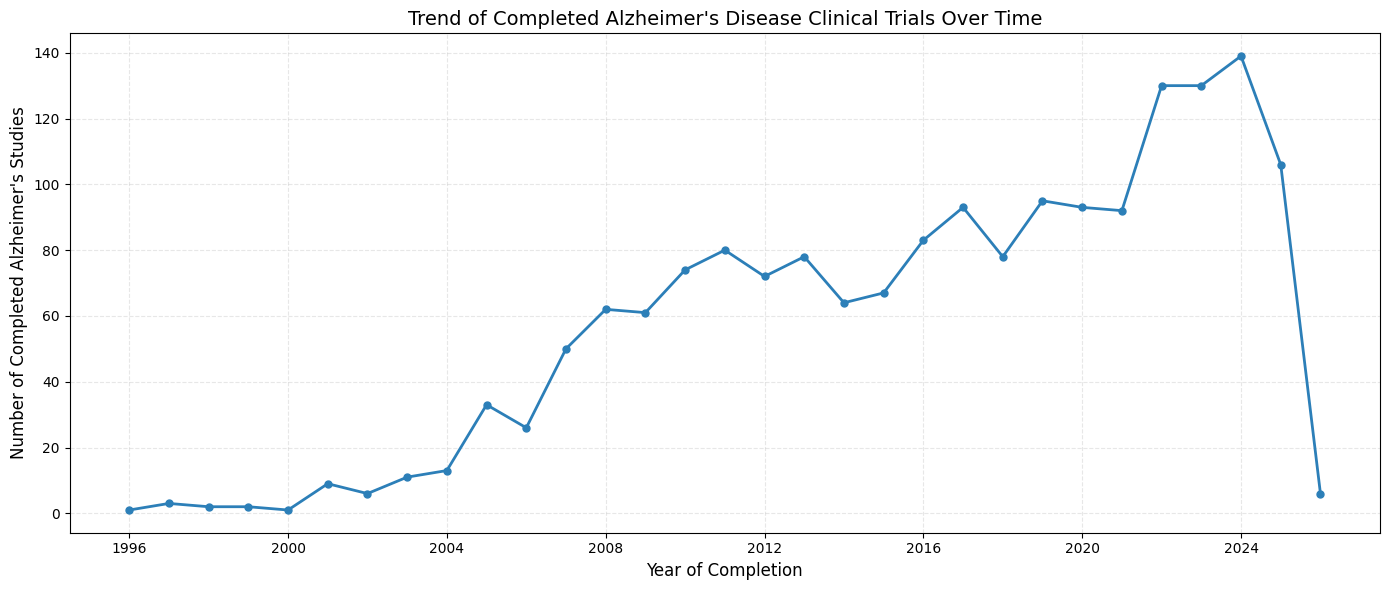

In [0]:
%python
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Convert to Pandas for plotting
# (one row per year) that this conversion is appropriate

viz_pd = annual_alzheimer_studies.toPandas()

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    viz_pd['completion_year'], 
    viz_pd['alzheimer_studies'], 
    marker='o', 
    linewidth=2, 
    color='#2c7fb8',
    markersize=5
)

ax.set_xlabel('Year of Completion', fontsize=12)
ax.set_ylabel("Number of Completed Alzheimer's Studies", fontsize=12)
ax.set_title("Trend of Completed Alzheimer's Disease Clinical Trials Over Time", fontsize=14)

# Ensure x-axis shows whole years only
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# gridlines will enhance readability
ax.grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

The trend shows a clear long-term growth trajectory in completed Alzheimer's clinical trials over three decades. Activity remained minimal through the late 1990s and early 2000s, with single-digit completions reflecting the emerging state of Alzheimer's-focused drug development. A sharp acceleration begins around 2003, climbing from roughly 5 studies to over 60 by 2008, coinciding with increased research funding driven by aging populations in developed countries and growing scientific interest in amyloid-targeting therapies.

From 2009 to 2018, activity plateaus and fluctuates between 60 and 95 completed studies per year. The periodic dips likely reflect the impact of several high-profile drug failures during this period, which temporarily dampened industry enthusiasm while prompting diversification into alternative approaches such as tau-targeting therapies and neuroinflammation research. Despite these setbacks, the overall level of activity remained robust.

The most striking feature is the surge from 2020 onward, peaking at approximately 139 completed studies in 2023. This aligns with renewed momentum following landmark regulatory approvals — notably aducanumab in 2021 and lecanemab in 2023 — which validated years of amyloid-focused research and triggered a wave of new trials. Increased government funding through initiatives like the US National Plan to Address Alzheimer's Disease also contributed to this peak.

However, the sharp drop-off in 2025–2026 should not be misread as a decline in research. This is a censoring effect — our filter only captures trials with a status of "Completed", and trials still in progress or recently concluded but not yet updated in the registry will not appear. Were this analysis repeated in a few years, these final data points would almost certainly fill in to continue the upward trend.

### Conclusion

This SQL analysis explored over 570,000 clinical trial records from ClinicalTrials.gov, demonstrating the effectiveness of distributed querying on a dataset with genuine Big Data characteristics.
The results tell a coherent story about the clinical research landscape. Interventional and observational studies dominate the registry, together accounting for over **99.5%** of all trials. The top conditions reflect clear public health priorities, with healthy volunteer studies topping the list (a consequence of Phase I safety trials) followed by major oncology, metabolic, and neurological conditions. Trials average around 35 months in duration, and the trend in completed Alzheimer's research shows three decades of sustained growth — peaking in 2023 alongside the first generation of successful amyloid-targeting drug approvals.

Beyond the answers themselves, the analysis highlighted the importance of careful data handling. Early exploration revealed column misalignment caused by unescaped delimiters, which was resolved by tuning the CSV parser. Date parsing, null handling, and assumption verification were approached deliberately rather than left to defaults. These choices reflect the reality that Big Data analysis is as much about understanding the data as it is about querying it.

Inbuilt SQL proved well-suited to the task throughout — particularly for handling multi-valued fields via LATERAL VIEW EXPLODE and for temporal calculations using MONTHS_BETWEEN. Aggregated results were converted to Pandas only for visualisation, to enable a clean presentation of findings.